In [1]:
%run shared_imports.py

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

In [3]:
query = select(Feedback.json, Feedback.datetime).filter(
    Feedback.key_name == 'job_preferences',
    Feedback.datetime >= datetime(2023, 7, 1))

In [4]:
df = pd.read_sql_query(query, session.connection())

In [5]:
def job_preferences(jobname):
    return lambda x: {pref: count for pref, count in x['data'][jobname].items() if pref in ('high', 'medium', 'low', 'never')}

In [6]:
df = df.join(pd.json_normalize(df.json.map(job_preferences('Captain')))).drop(['json'], axis=1)
df['dt'] = pd.to_datetime(df.datetime.dt.year.astype(str) + df.datetime.dt.month.astype(str), format='%Y%m')
df.drop(['datetime'], inplace=True, axis=1)

In [7]:
summed = df.groupby(['dt']).sum().astype(int)

In [9]:
cols = ['high', 'medium', 'low', 'never']
summed[cols] = summed[cols].div(summed[cols].sum(axis=1), axis=0).multiply(100)

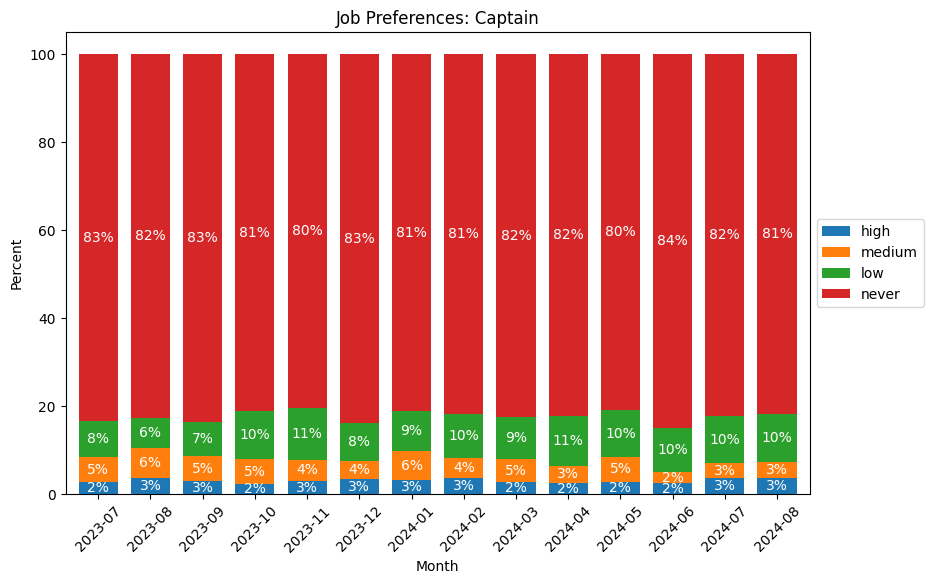

In [11]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

plot = summed.plot(kind='bar', stacked=True, ax=ax, width=0.75)
for c in ax.containers:
    labels = [f"{int(v.get_height())}%" if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white')
ax.set_xticklabels([x.strftime("%Y-%m") for x in summed.index], rotation=45)

plt.title("Job Preferences: Captain")
ax.set_xlabel('Month')
ax.set_ylabel('Percent')
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('vampire_subclass_percentage.png')